# Динамика Daisyworld при изменении светимости
В этом сценарии мы исследуем, как планета адаптируется к постепенному
изменению солнечной активности (сценарий `:ramp`). Мы проследим за
численностью маргариток, средней температурой и уровнем светимости.

In [1]:
using DrWatson
@quickactivate "project"

using Agents, DataFrames, CairoMakie, Statistics
include(srcdir("daisyworld.jl"))

daisyworld (generic function with 1 method)

## Настройка сбора данных
Определяем функции для подсчета маргариток разных видов.

In [2]:
black(a) = a.breed == :black
white(a) = a.breed == :white
adata = [(black, count), (white, count)]

2-element Vector{Tuple{Function, typeof(count)}}:
 (Main.var"##226".black, count)
 (Main.var"##226".white, count)

Определяем функции для сбора данных о модели (средняя температура и светимость).

In [3]:
temperature(model) = mean(model.temperature)
mdata = [temperature, :solar_luminosity]

2-element Vector{Any}:
 temperature (generic function with 1 method)
 :solar_luminosity

## Запуск симуляции
Инициализируем модель с начальной светимостью 1.0 и сценарием постепенного изменения (`:ramp`).
Запускаем модель на 1000 шагов.

In [4]:
model = daisyworld(; solar_luminosity = 1.0, scenario = :ramp)
agent_df, model_df = run!(model, 1000; adata = adata, mdata = mdata)

(1001×3 DataFrame
  Row │ time   count_black  count_white 
      │ Int64  Int64        Int64       
──────┼─────────────────────────────────
    1 │     0          180          180
    2 │     1          408          167
    3 │     2          523          217
    4 │     3          565          285
    5 │     4          565          323
    6 │     5          561          334
    7 │     6          563          333
    8 │     7          559          334
  ⋮   │   ⋮         ⋮            ⋮
  995 │   994            0          899
  996 │   995            0          897
  997 │   996            0          893
  998 │   997            0          895
  999 │   998            0          894
 1000 │   999            0          889
 1001 │  1000            0          879
                        986 rows omitted, 1001×3 DataFrame
  Row │ time   temperature  solar_luminosity 
      │ Int64  Float64      Float64          
──────┼──────────────────────────────────────
    1 │     0     16.9135  

## Визуализация результатов
Создаем сложный график с тремя панелями для детального анализа.

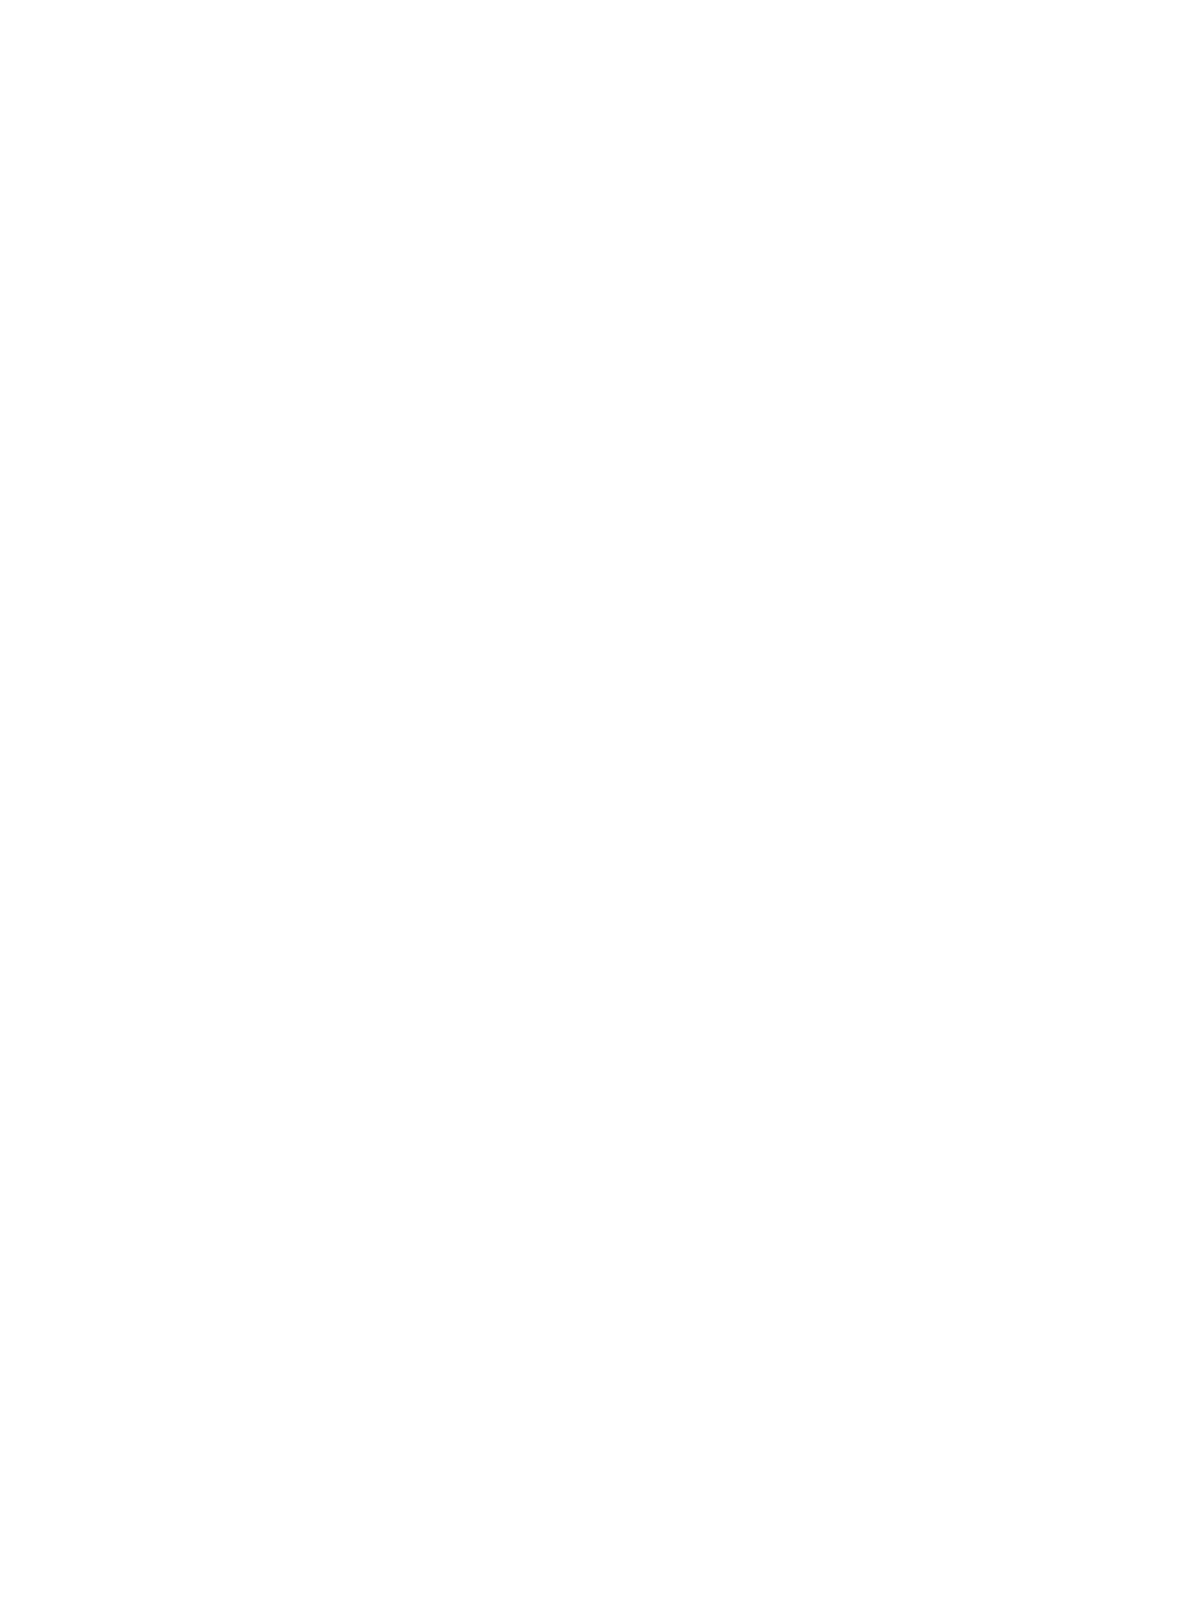

In [5]:
figure = Figure(size = (600, 800))

### Панель 1: Численность популяций

In [6]:
ax1 = figure[1, 1] = Axis(figure, ylabel = "Число маргариток")
blackl = lines!(ax1, agent_df[!, :time], agent_df[!, :count_black], color = :black)
whitel = lines!(ax1, agent_df[!, :time], agent_df[!, :count_white], color = :blue)
figure[1, 2] = Legend(figure, [blackl, whitel], ["Черные", "Белые"])

Legend()

### Панель 2: Средняя температура

In [7]:
ax2 = figure[2, 1] = Axis(figure, ylabel = "Температура")
lines!(ax2, model_df[!, :time], model_df[!, :temperature], color = :red)

Lines{Tuple{Vector{Point{2, Float64}}}}

### Панель 3: Изменение светимости солнца

In [8]:
ax3 = figure[3, 1] = Axis(figure, xlabel = "Тики (время)", ylabel = "Светимость")
lines!(ax3, model_df[!, :time], model_df[!, :solar_luminosity], color = :orange)

Lines{Tuple{Vector{Point{2, Float64}}}}

## Оформление графика
Убираем лишние подписи осей X для верхних графиков, чтобы они не накладывались друг на друга.

In [9]:
for ax in (ax1, ax2)
    ax.xticklabelsvisible = false
end

Сохраняем результат в папку с графиками.

In [10]:
mkpath(plotsdir())
save(plotsdir("daisy_luminosity.png"), figure)

Отображаем финальную фигуру:

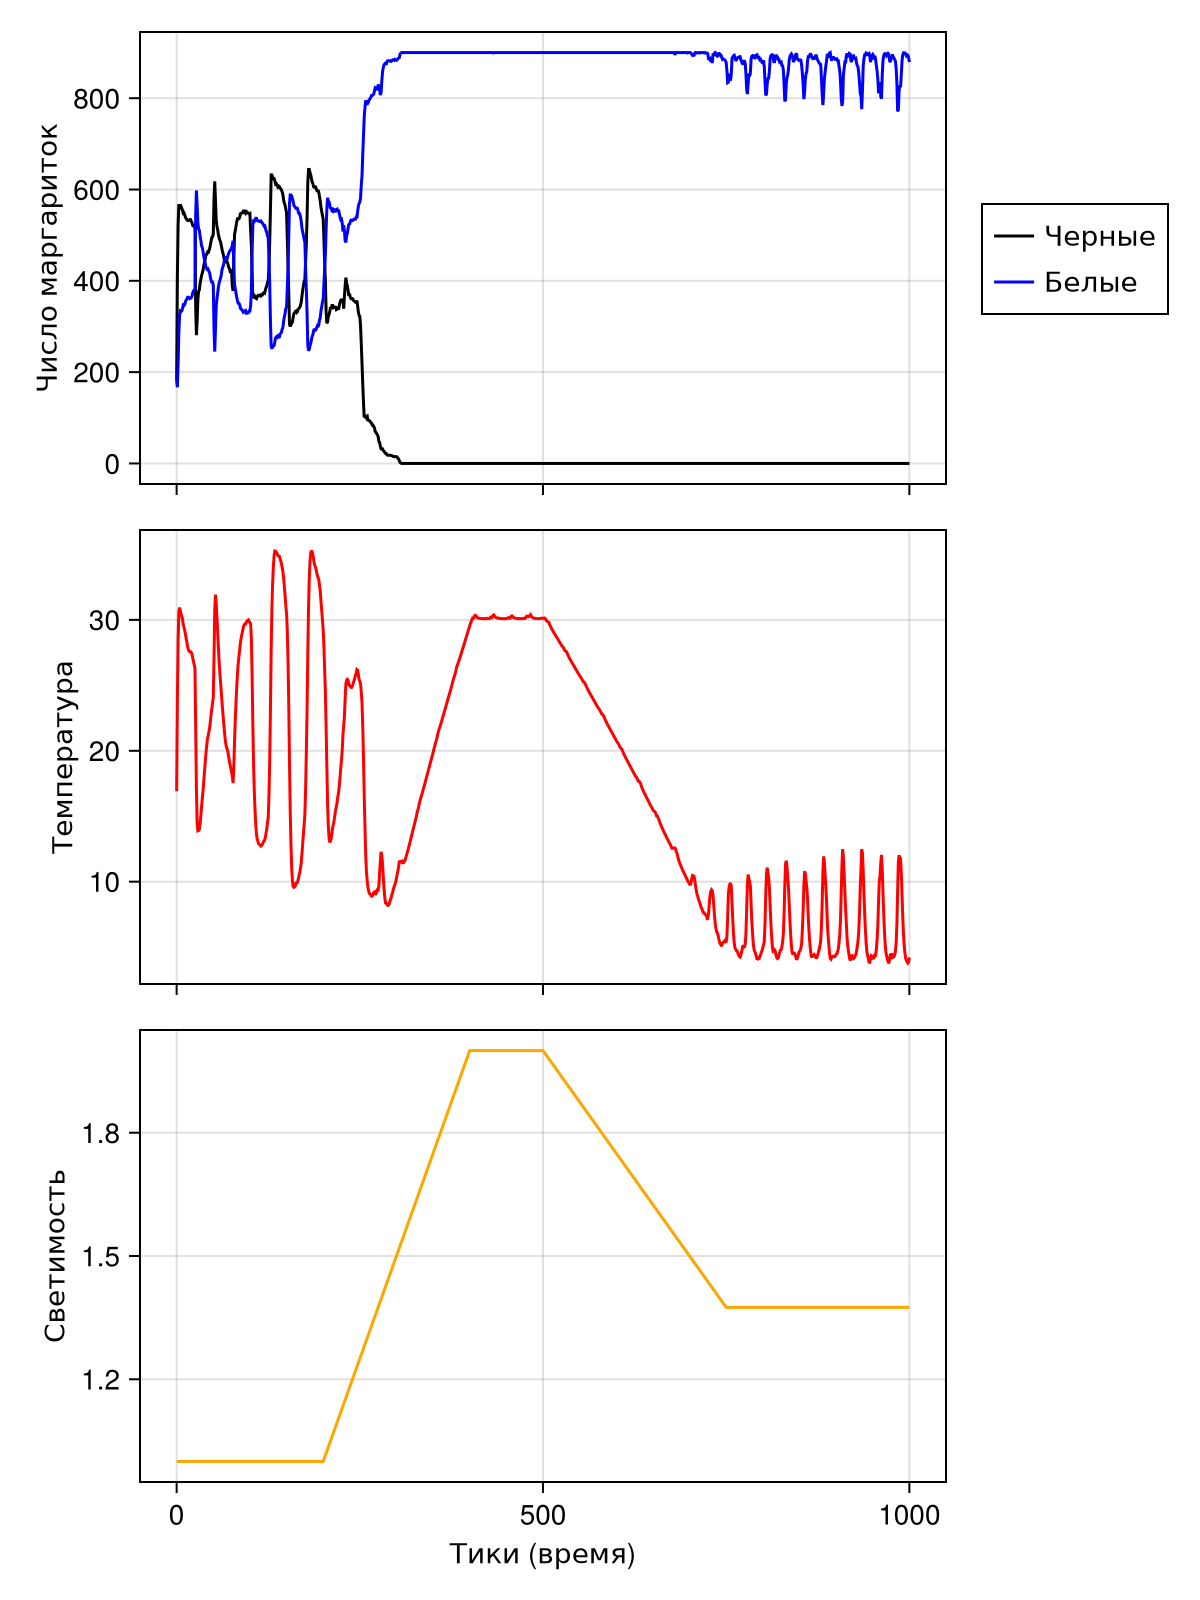

In [11]:
figure

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*